<a href="https://colab.research.google.com/github/Geppetto0608/YOLO-example/blob/main/YOLO_apple_0928.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
model = YOLO('yolo26n.pt')

In [ ]:
import torch

model = torch.load("yolo26n.pt",map_location='cpu',weights_only=False)
print(model['model'].names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pwd

/content


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="2u293ucDlCWIMFYMhkrV")
project = rf.workspace("trash-ltbe2").project("apples-m8jws")
version = project.version(1)
dataset = version.download("yolo26")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to apples-1 in yolo26:: 100%|██████████| 18811/18811 [00:03<00:00, 5738.86it/s]


In [ ]:
from ultralytics import YOLO
import os

os.makedirs('content/runs', exist_ok=True)
model = YOLO('/yolo26n.pt')
model.train(
    data='content/roboflow/data.yaml',
    epochs=3,
    imgsz=256,
    batch=16,
    workers = 4,
    fraction=0.3,
    project = '/content/runs',
    name='exp'

)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=content/roboflow/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.3, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp-2, nbs=64, nms=None, opset=None, optimize=False, optimizer=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79fa450deb10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
model = YOLO('/content/runs/exp/weights/best.pt')
validation_data = '/content/roboflow/data.yaml'
metrics = model.val(data=validation_data)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1388.6±713.8 MB/s, size: 34.9 KB)
val: Scanning /content/roboflow/valid/labels.cache... 1880 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1880/1880 375.5Mit/s 0.0s
val: /content/roboflow/valid/images/-00064_jpeg_jpg.rf.988d03c014c120c1f4134079e5e7bae1.jpg: 1 duplicate labels removed
val: /content/roboflow/valid/images/-00103_jpeg_jpg.rf.38b5f9ad7333b392c6115d4408f6b381.jpg: 1 duplicate labels removed
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 380, len(boxes) = 3843. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
# 학습된 모델 로드
model = YOLO('/content/runs/exp/weights/best.pt')
# 검증 데이터셋 설정 (예: coco128.yaml 파일)
validation_data = '/content/roboflow/data.yaml'
# 모델 검증
metrics = model.val(data=validation_data)
# 성능 지표 출력
# 'Precision' = 정밀도
# => 모델이 예측한 객체 중 실제로 올바르게 예측된 객체의 비율
# 'Recall' = 재현율
# => 실제 객체 중 모델이 올바르게 검출한 객체의 비율
# 'mAP@0.5' = IoU=0.5에서의 Mean Average Precision
# 'mAP@0.5:0.95' = IoU=0.5~0.95에서의 평균 mAP
# => 높을수록 성능이 좋은 모델
precision = metrics.box.p
recall = metrics.box.r
map_50 = metrics.box.map50
map_50_95 = metrics.box.map
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"mAP@0.5: {map_50}")
print(f"mAP@0.5:0.95: {map_50_95}")
# confusion matrix 출력
print(metrics.confusion_matrix.matrix)

Ultralytics 8.4.165 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 120 layers, 2,375,421 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1455.2±579.0 MB/s, size: 29.4 KB)
val: Scanning /content/roboflow/valid/labels.cache... 1880 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1880/1880 375.5Mit/s 0.0s
val: /content/roboflow/valid/images/-00064_jpeg_jpg.rf.988d03c014c120c1f4134079e5e7bae1.jpg: 1 duplicate labels removed
val: /content/roboflow/valid/images/-00103_jpeg_jpg.rf.38b5f9ad7333b392c6115d4408f6b381.jpg: 1 duplicate labels removed
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 380, len(boxes) = 3843. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!ls /content/runs/detect/val/

BoxF1_curve.png  confusion_matrix_normalized.png  val_batch1_labels.jpg
BoxP_curve.png	 confusion_matrix.png		  val_batch1_pred.jpg
BoxPR_curve.png  val_batch0_labels.jpg		  val_batch2_labels.jpg
BoxR_curve.png	 val_batch0_pred.jpg		  val_batch2_pred.jpg


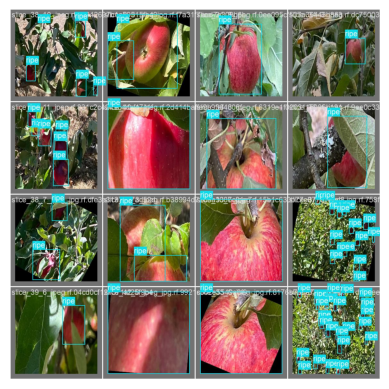

In [ ]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"
!pip install pillow
from PIL import Image
import matplotlib.pyplot as plt
# 이미지 파일 경로 설정 (예: 'example.jpg')
image_path = '/content/runs/detect/val/val_batch1_labels.jpg'
# 이미지 열기
img = Image.open(image_path)
# 이미지 표시
plt.imshow(img)
plt.axis('off')  # 축 숨기기
plt.show()

In [ ]:
# 1. 필요한 라이브러리 설치
!pip install -q ultralytics yt-dlp

from ultralytics import YOLO

# =========================================================
# 2. 학습한 사과 YOLO 모델 불러오기
# =========================================================

model_path = "/content/runs/exp/weights/best.pt"
model = YOLO(model_path)

print(model.names)
# {0: 'bad', 1: 'ripe', 2: 'unripe'}

# =========================================================
# 3. YOLO Detection - 처음 2000프레임까지만
# =========================================================

results = model.predict(
    source="/content/apple_test.mp4",

    conf=0.25,
    iou=0.45,

    save=True,
    show=False,
    stream=True,   # 프레임 단위 처리

    project="/content/youtube_results",
    name="apple_detection",
    exist_ok=True
)

MAX_FRAMES = 2000

for i, result in enumerate(results):

    if (i + 1) % 100 == 0:
        print(f"{i + 1} / {MAX_FRAMES} 프레임 처리 완료")

    if i + 1 >= MAX_FRAMES:
        break

print("Detection 완료")
print(f"처리 프레임 수: {MAX_FRAMES}")
print("저장 위치: /content/youtube_results/apple_detection/")

{0: 'bad', 1: 'ripe', 2: 'unripe'}

video 1/1 (frame 1/4155) /content/apple_test.mp4: 160x256 8 ripes, 8.8ms
video 1/1 (frame 2/4155) /content/apple_test.mp4: 160x256 8 ripes, 11.0ms
video 1/1 (frame 3/4155) /content/apple_test.mp4: 160x256 8 ripes, 16.3ms
video 1/1 (frame 4/4155) /content/apple_test.mp4: 160x256 8 ripes, 18.9ms
video 1/1 (frame 5/4155) /content/apple_test.mp4: 160x256 8 ripes, 30.4ms
video 1/1 (frame 6/4155) /content/apple_test.mp4: 160x256 8 ripes, 43.5ms
video 1/1 (frame 7/4155) /content/apple_test.mp4: 160x256 8 ripes, 22.5ms
video 1/1 (frame 8/4155) /content/apple_test.mp4: 160x256 8 ripes, 42.9ms
video 1/1 (frame 9/4155) /content/apple_test.mp4: 160x256 8 ripes, 44.5ms
video 1/1 (frame 10/4155) /content/apple_test.mp4: 160x256 8 ripes, 40.9ms
video 1/1 (frame 11/4155) /content/apple_test.mp4: 160x256 8 ripes, 17.9ms
video 1/1 (frame 12/4155) /content/apple_test.mp4: 160x256 8 ripes, 15.4ms
video 1/1 (frame 13/4155) /content/apple_test.mp4: 160x256 8 ripes, 26.6ms